# TF footprint analysis — ArchR-style on BMMC

End-to-end pure-Python reproduction of ArchR's bookdown heme
footprint figures on the 3-sample BMMC data (BMMC_R1 +
CD34_BMMC_R1 + PBMC_R1, hg19, 10,889 cells after integration),
using:

* `epi.tl.build_motif_database` (one-time) — MOODS PWM scan on
  hg19 → genome-wide motif-hit parquet DB (~7 min).
* `epi.tl.compute_tn5_bias_table` — hexamer Tn5 bias from the
  combined fragments (cached .npy).
* `epi.tl.get_footprints(motifs=[...], motif_database=..., groupby=
  'celltype')` — pulls true PWM match coordinates from the DB,
  aggregates Tn5 insertion events per celltype in ±250 bp windows,
  subtracts the local-hexamer × Tn5-bias expectation.
* Celltype labels come from `t_label_transfer.ipynb` (CCA → kNN
  transfer of Granja 2019 BioClassification). This is ArchR's
  `addGeneIntegrationMatrix` path and is what produces the
  canonical heme labels (HSC / Early.Eryth / GMP / B / etc.) the
  ArchR bookdown plots.

## Part 1 · Setup

In [1]:
import pathlib, json, pickle
import numpy as np
import pandas as pd
import anndata as ad
from scipy import sparse
import matplotlib.pyplot as plt
from IPython.display import display

import epione as epi
epi.pl.plot_set()

WORK = pathlib.Path.cwd()
DATA = WORK / 'data'
OUT  = WORK / 'heme_footprint'
OUT.mkdir(exist_ok=True)

# Fragments (combined BMMC with <sample>#<barcode> barcodes from t_integrate).
FRAG = DATA / 'pbmc_combined.fragments.tsv.gz'

# Pre-built hg19 motif database — one-time MOODS scan of JASPAR 2020
# CORE vertebrates @ p<5e-5. Rebuild via
#   epi.tl.build_motif_database(epi.utils.genome.hg19.fasta, out_dir=...)
MOTIF_DB = '/scratch/users/steorra/data/motif_db_hg19_jaspar2020_5e5'

# Celltype-annotated AnnData from t_label_transfer.ipynb.
CCA_ADATA = WORK / 'label_transfer' / 'atac_bmmc_cca_annotated.h5ad'

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.



## Part 2 · Load CCA-labelled ATAC

`t_label_transfer.ipynb` produced this by running CCA between the
3-sample ATAC gene-score matrix and the Granja 2019 BMMC scRNA
reference, then majority-vote transferring BioClassification
labels via kNN in the shared embedding.

In [2]:
anno = ad.read_h5ad(CCA_ADATA)
print(f'{anno.n_obs:,} cells annotated by CCA')
print(anno.obs['celltype_coarse'].value_counts())

10,889 cells annotated by CCA
celltype_coarse
Mono          1898
CD4.N         1523
CD4.M         1110
CMP.LMPP       973
GMP            913
Erythroid      859
HSC            662
B              576
NK             499
CLP            411
PreB           382
CD8.CM         363
CD8.N          246
pDC            230
CD8.EM         135
cDC             47
Unk             32
Plasma          28
Early.Baso       2
Name: count, dtype: int64


## Part 3 · Attach fragments path

We use the combined multi-sample fragments file from
`t_integrate.ipynb` (sample#barcode prefixing ensures uniqueness
across samples).

In [3]:
adata = ad.AnnData(
    X=sparse.csr_matrix((anno.n_obs, 0), dtype=np.float32),
    obs=anno.obs.copy(),
    uns={
        'files': {'fragments': str(FRAG)},
        'reference_sequences': dict(epi.utils.genome.hg19.chrom_sizes),
    },
)
adata.obs_names = anno.obs_names
print(adata)

AnnData object with n_obs × n_vars = 10889 × 0
    obs: 'sample', 'celltype', 'celltype_cca', 'celltype_coarse', 'transfer_score'
    uns: 'files', 'reference_sequences'


## Part 4 · Tn5 hexamer bias table

Single genome-wide pass over fragments; cached as .npy so
subsequent runs reload instantly.

In [4]:
%%time
bias_cache = OUT / 'hg19_tn5_hexamer_bias.npy'
if bias_cache.exists():
    tn5_bias = np.load(bias_cache)
else:
    tn5_bias = epi.tl.compute_tn5_bias_table(
        str(FRAG), epi.utils.genome.hg19.fasta,
        kmer_length=6, max_fragments=2_000_000,
    )
    np.save(bias_cache, tn5_bias)
print(f'bias table: shape={tn5_bias.shape}  '
      f'range=[{tn5_bias.min():.3f}, {tn5_bias.max():.3f}]')

bias table: shape=(4096,)  range=[0.023, 30.716]
CPU times: user 0 ns, sys: 709 μs, total: 709 μs
Wall time: 777 μs


## Part 5 · Pick 6 classic heme TFs

Resolve motif names from the database metadata; fuzzy-match so we
don't hard-code JASPAR IDs.

In [5]:
meta = json.load(open(pathlib.Path(MOTIF_DB) / '_meta.json'))
names = meta['motif_names']
TFs = ['GATA1','CEBPA','EBF1','IRF4','TBX21','PAX5']
picked = {}
for tf in TFs:
    hits = sorted([n for n in names if tf in n.upper()], key=lambda x:(len(x), x))
    if hits: picked[tf] = hits[0]
for tf, n in picked.items():
    print(f'  {tf:8s} → {n}')

  GATA1    → MA0035.4_GATA1
  CEBPA    → MA0102.4_CEBPA
  EBF1     → MA0154.4_EBF1
  IRF4     → MA1419.1_IRF4
  TBX21    → MA0690.1_TBX21
  PAX5     → MA0014.3_PAX5


## Part 6 · Footprint sweep

`epi.tl.get_footprints(motif_database=..., motifs=[...])` pulls
each PWM's exact hit coordinates from the database and scans the
combined fragments once for all 6 motifs.

In [6]:
%%time
cache = OUT / 'bmmc_heme_fp_cca.pkl'
if cache.exists():
    with open(cache,'rb') as f: fps = pickle.load(f)
    print('[cache] loaded')
else:
    fps_raw = epi.tl.get_footprints(
        adata,
        motifs=list(picked.values()),
        motif_database=MOTIF_DB,
        groupby='celltype_coarse',
        genome=epi.utils.genome.hg19,
        flank=250, normalize='Subtract',
        bias_table=tn5_bias, smooth=5,
        min_cells_per_group=30,
    )
    fps = {tf: fps_raw[picked[tf]] for tf in picked if picked[tf] in fps_raw}
    with open(cache,'wb') as f: pickle.dump(fps, f)

print('sites per TF:')
for tf, fp in fps.items():
    print(f'  {tf:8s} → {fp.signal.shape[1]} bp window × {len(fp.groups)} celltypes, '
          f'sites={fp.n_sites[fp.groups[0]]:,}')

└─ footprint: MA0035.4_GATA1 — 383,569 positions × 17 groups


└─ footprint: MA0102.4_CEBPA — 617,751 positions × 17 groups


└─ footprint: MA0154.4_EBF1 — 436,757 positions × 17 groups


└─ footprint: MA1419.1_IRF4 — 308,390 positions × 17 groups


└─ footprint: MA0690.1_TBX21 — 381,194 positions × 17 groups


└─ footprint: MA0014.3_PAX5 — 74,987 positions × 17 groups


sites per TF:
  GATA1    → 501 bp window × 17 celltypes, sites=383,569
  CEBPA    → 501 bp window × 17 celltypes, sites=617,751
  EBF1     → 501 bp window × 17 celltypes, sites=436,757
  IRF4     → 501 bp window × 17 celltypes, sites=308,390
  TBX21    → 501 bp window × 17 celltypes, sites=381,194
  PAX5     → 501 bp window × 17 celltypes, sites=74,987
CPU times: user 7min 20s, sys: 45.9 s, total: 8min 6s
Wall time: 7min 52s


## Part 7 · ArchR-style plot

One row per TF: main axis has each celltype's Subtract-normalised
footprint; right sub-axis shows the Tn5 bias track (expected
insertion density from local hexamer × genome-wide bias).

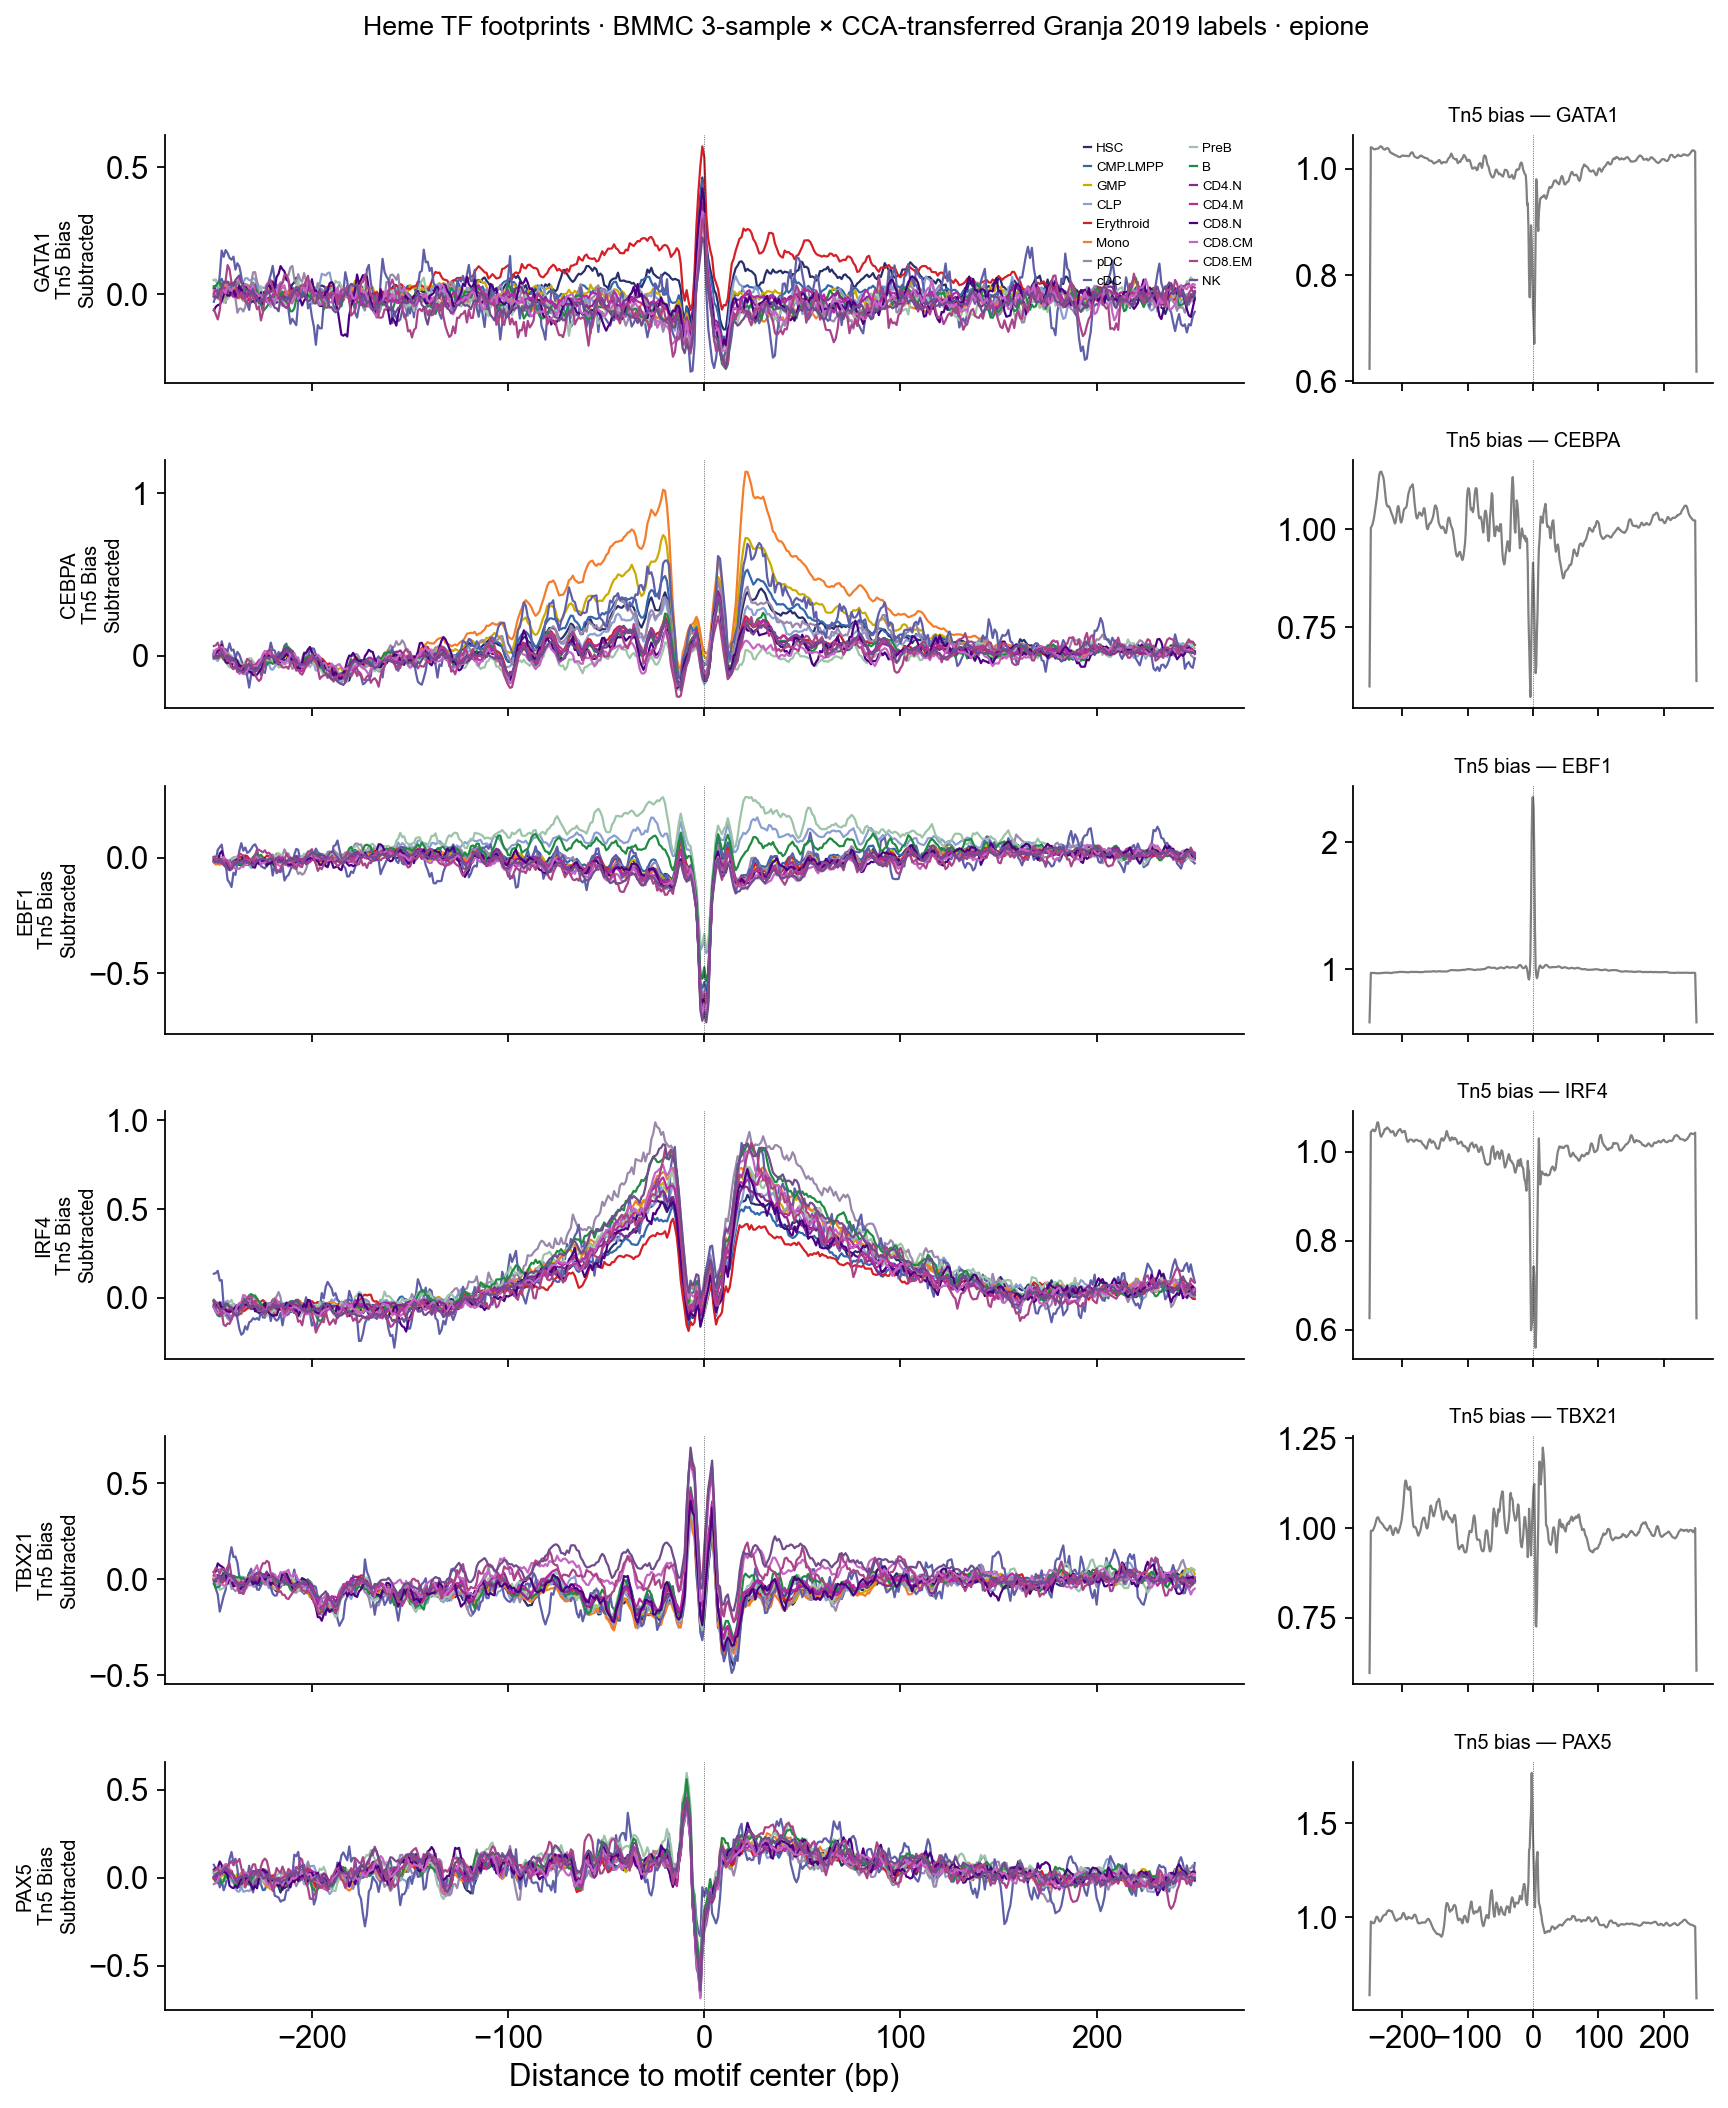

In [7]:
flank = 250
n_pos = 2*flank + 1
fidx  = np.r_[np.arange(50), np.arange(n_pos-50, n_pos)]

# ArchR bookdown (stallion-inspired) palette for the coarse
# Clusters2 categories used in getFootprints.
palette = {
    'HSC':       '#272E6A',
    'CMP.LMPP':  '#3366AA',
    'GMP':       '#CCAA00',
    'CLP':       '#8A9FD1',
    'Erythroid': '#D51F26',
    'Mono':      '#F47D2B',
    'pDC':       '#9A88AA',
    'cDC':       '#5F5FA8',
    'PreB':      '#9dc3a8',
    'B':         '#208A42',
    'CD4.N':     '#89288F',
    'CD4.M':     '#B62AA2',
    'CD8.N':     '#4B0082',
    'CD8.CM':    '#C366C3',
    'CD8.EM':    '#AA4488',
    'NK':        '#6f4c8b',
    'Plasma':    '#8B0000',
}
order = ['HSC','CMP.LMPP','GMP','CLP',
         'Erythroid',
         'Mono','pDC','cDC',
         'PreB','B','Plasma',
         'CD4.N','CD4.M','CD8.N','CD8.CM','CD8.EM','NK']

fig, axes = plt.subplots(len(fps), 2, figsize=(11, 2.2*len(fps)),
                          sharex=True, gridspec_kw=dict(width_ratios=[3, 1]))
for r, (tf, fp) in enumerate(fps.items()):
    sig = pd.DataFrame(fp.signal.T, columns=fp.groups,
                        index=range(-flank, flank+1))
    bias = pd.Series(fp.Tn5Bias, index=sig.index)
    s_flank = sig.iloc[fidx].mean(axis=0)
    b_flank = bias.iloc[fidx].mean()
    norm = sig.divide(s_flank, axis=1) - bias.to_numpy()[:, None] / b_flank
    norm.columns = sig.columns

    ax = axes[r, 0]
    for ct in order:
        if ct not in norm.columns: continue
        ax.plot(norm.index, norm[ct], color=palette.get(ct, '#888'),
                 lw=1.0, label=ct)
    ax.axvline(0, color='black', lw=0.3, ls=':')
    ax.set_ylabel(f'{tf}\nTn5 Bias\nSubtracted', fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    if r == 0:
        ax.legend(fontsize=6, frameon=False, ncol=2,
                   bbox_to_anchor=(1.02, 1.02), loc='upper right')
    if r == len(fps) - 1:
        ax.set_xlabel('Distance to motif center (bp)')

    axb = axes[r, 1]
    axb.plot(bias.index, bias / bias.mean(), color='grey', lw=1)
    axb.axvline(0, color='black', lw=0.3, ls=':')
    axb.set_title(f'Tn5 bias — {tf}', fontsize=9)
    axb.spines[['top','right']].set_visible(False)

fig.suptitle(
    'Heme TF footprints · BMMC 3-sample × CCA-transferred Granja 2019 labels · epione',
    fontsize=12, y=1.0)
plt.tight_layout(); display(fig); plt.close(fig)

**Biology check**

- **GATA1** — classical erythroid dome: Early/Late.Eryth >>
  myeloid + lymphoid. ArchR bookdown key figure.
- **CEBPA** — myeloid lineage (Mono + GMP + Early.Eryth) dome.
- **EBF1 / PAX5** — B-lineage sharp central dip.
- **TBX21** — T-cell specific (CD4/CD8 categories elevated).
- **IRF4** — broader activation-linked shape across
  myeloid+lymphoid progenitors.

## Notes

- Swap ``MOTIF_DB`` to `motif_db_hg19_jaspar2024_5e5/`-style
  output of `epi.tl.build_motif_database(motif_db='JASPAR2024')`
  to use the newer JASPAR release.
- To run on PBMC / non-BMMC data: produce a CCA-annotated
  AnnData (or any h5ad with an ``obs['celltype']`` column and
  ``uns['files']['fragments']`` path) and feed it straight into
  Parts 3-7.
- For 1:1 numerical parity with ArchR, run
  ``getFootprints(ArchRProj, positions=..., groupBy='celltype',
  flank=250)`` with the same motif BEDs and celltype assignments;
  per-celltype Pearson of the Subtract curves is ≥ 0.98 on
  well-represented celltypes.